# UK Biobank Showcase+ citation and disciplinary figures

This notebook makes the disciplinary and citation figures from the publication-level full-endpoint parquet. It does not run BERTopic and does not depend on any topic-model cache.

The input is `showcase_plus_all_endpoints_wide.parquet`. The analysis uses its publication fields only, so every figure is calculated from the same one-row-per-paper table. Figures are shown in the notebook and saved to Google Drive as PNG, PDF and SVG files; the tables behind them are saved as CSV files.

Topic waves and other BERTopic outputs are deliberately kept in the topic notebook. The earlier source-route comparison is also omitted because `source_route` is not a field in the full-endpoint parquet and would require a second input table.


## 1. set the input




In [1]:
from pathlib import Path
import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Google Colab is not active; using the configured local paths.")

DRIVE_PROJECT = Path("/content/drive/MyDrive/UKB_BERTopic_seed_robustness")
PARQUET_PATH = Path(
    os.environ.get(
        "UKB_FULL_ENDPOINT_PARQUET",
        DRIVE_PROJECT / "input" / "showcase_plus_all_endpoints_wide.parquet",
    )
)
OUTPUT_DIR = Path(
    os.environ.get(
        "UKB_NON_TOPIC_OUTPUT",
        DRIVE_PROJECT / "output" / "non_topic_figures",
    )
)
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for directory in (FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        f"Full-endpoint parquet not found: {PARQUET_PATH}\n"
        "Update DRIVE_PROJECT or PARQUET_PATH, then run this cell again."
    )

print(f"Input: {PARQUET_PATH}")
print(f"Figures: {FIGURE_DIR}")
print(f"Tables: {TABLE_DIR}")


Mounted at /content/drive
Input: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/input/showcase_plus_all_endpoints_wide.parquet
Figures: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures
Tables: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/tables


## 2. Analysis settings and shared style

The current export includes an incomplete 2026 cohort, so trend figures stop at 2025. The citation snapshot year is kept explicit because it is used to calculate citations per year.


In [2]:
import ast
import json
import re
from textwrap import wrap

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

MIN_YEAR = 2014
INCOMPLETE_YEARS = {2026}
CITATION_SNAPSHOT_YEAR = 2026
TOP_N = 15
MIN_VENUE_PAPERS = 20

COLOUR = {
    "blue_dark": "#344874",
    "gold": "#FFBB00",
    "blue": "#5B8DB8",
    "teal": "#2A9D8F",
    "coral": "#E76F51",
    "purple": "#8E6C9E",
    "grey_dark": "#3A3A3A",
    "grey": "#777777",
    "grey_light": "#E8E8E8",
}

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.3,
    "ytick.labelsize": 9.3,
    "legend.fontsize": 8.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

impact_cmap = LinearSegmentedColormap.from_list(
    "ukb_impact", ["#E5EDF5", COLOUR["blue"], COLOUR["blue_dark"]]
)
field_cmap = LinearSegmentedColormap.from_list(
    "ukb_field", ["#E4F3EF", COLOUR["teal"], "#17645D"]
)


## 3. Load the publication table

Only the columns needed below are read from the wide parquet. Duplicate publication IDs are checked and collapsed before analysis, so one paper cannot be counted twice because of the endpoint merge.


In [3]:
PUBLICATION_COLUMNS = [
    "id",
    "title",
    "year",
    "times_cited",
    "field_citation_ratio",
    "relative_citation_ratio",
    "source_title",
    "category_for_2020",
]

papers = pd.read_parquet(PARQUET_PATH, columns=PUBLICATION_COLUMNS)

missing = [column for column in PUBLICATION_COLUMNS if column not in papers.columns]
if missing:
    raise ValueError(f"The parquet is missing required publication columns: {missing}")

input_rows = len(papers)
duplicate_ids = int(papers["id"].duplicated(keep=False).sum())
papers = papers.drop_duplicates(subset="id", keep="first").copy()

papers["year"] = pd.to_numeric(papers["year"], errors="coerce")
papers["times_cited"] = pd.to_numeric(papers["times_cited"], errors="coerce").fillna(0)
papers["field_citation_ratio"] = pd.to_numeric(
    papers["field_citation_ratio"], errors="coerce"
)
papers["relative_citation_ratio"] = pd.to_numeric(
    papers["relative_citation_ratio"], errors="coerce"
)

analysis_papers = papers[
    papers["year"].notna()
    & papers["year"].ge(MIN_YEAR)
    & ~papers["year"].isin(INCOMPLETE_YEARS)
].copy()
analysis_papers["year"] = analysis_papers["year"].astype(int)
analysis_papers["citation_age_years"] = (
    CITATION_SNAPSHOT_YEAR - analysis_papers["year"] + 1
).clip(lower=1)
analysis_papers["citations_per_year"] = (
    analysis_papers["times_cited"] / analysis_papers["citation_age_years"]
)

if analysis_papers.empty:
    raise ValueError("No eligible publication rows remain after the year checks.")

print(f"Rows read: {input_rows:,}")
print(f"Duplicate-ID rows found: {duplicate_ids:,}")
print(f"Unique publications: {len(papers):,}")
print(
    f"Complete-year analysis set: {len(analysis_papers):,} "
    f"({analysis_papers['year'].min()}-{analysis_papers['year'].max()})"
)
display(analysis_papers.head(3))


Rows read: 26,109
Duplicate-ID rows found: 0
Unique publications: 26,109
Complete-year analysis set: 23,437 (2014-2025)


,id,title,year,times_cited,field_citation_ratio,relative_citation_ratio,source_title,category_for_2020,citation_age_years,citations_per_year
0,pub.1000169743,Ethnic-Specific Obesity Cutoffs for Diabetes R...,2014,223,32.97,5.16,"{""id"":""jour.1103715"",""title"":""Diabetes Care""}","[{""id"":""80003"",""name"":""32 Biomedical and Clini...",13,17.153846
1,pub.1000305094,Data science for mental health: a UK perspecti...,2016,56,8.91,1.36,"{""id"":""jour.1050550"",""title"":""The Lancet Psych...","[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,5.090909
2,pub.1001609820,"Ambient air pollution, traffic noise and adult...",2016,73,22.92,2.67,"{""id"":""jour.1097884"",""title"":""European Respira...","[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,6.636364


## 4. Prepare journal and Field of Research values

Dimensions stores journals and Fields of Research as JSON-like values. This cell turns them into ordinary labels. Four-digit FoR 2020 groups are used for the field plots. When a paper has several groups, its weight is split equally between them rather than counted several times.


In [4]:
def parse_json_like(value):
    if isinstance(value, (list, dict)):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return text


def clean_source_title(value):
    parsed = parse_json_like(value)
    if isinstance(parsed, dict):
        return str(parsed.get("title") or parsed.get("name") or "").strip()
    if isinstance(parsed, list) and parsed:
        return clean_source_title(parsed[0])
    return re.sub(r"\s+", " ", str(parsed or "")).strip()


def four_digit_for_groups(value):
    parsed = parse_json_like(value)
    if isinstance(parsed, dict):
        parsed = [parsed]
    if not isinstance(parsed, list):
        return []

    groups = {}
    for item in parsed:
        if isinstance(item, dict):
            name = str(item.get("name") or item.get("title") or "").strip()
        else:
            name = str(item).strip()
        match = re.match(r"^(\d{4})\s+(.+)$", name)
        if match:
            groups[match.group(1)] = match.group(2).strip()
    return sorted(groups.items())


def wrapped(text, width=38):
    return "\n".join(wrap(str(text), width=width))


def save_figure(figure, stem):
    for extension in ("png", "pdf", "svg"):
        figure.savefig(
            FIGURE_DIR / f"{stem}.{extension}",
            bbox_inches="tight",
            facecolor="white",
        )
    print(f"Saved: {FIGURE_DIR / (stem + '.png')}")


analysis_papers["venue"] = analysis_papers["source_title"].map(clean_source_title)

for_rows = []
for row in analysis_papers[
    ["id", "year", "times_cited", "category_for_2020"]
].itertuples(index=False):
    groups = four_digit_for_groups(row.category_for_2020)
    if not groups:
        continue
    weight = 1.0 / len(groups)
    for code_value, field_name in groups:
        for_rows.append({
            "id": row.id,
            "year": row.year,
            "times_cited": row.times_cited,
            "for_code": code_value,
            "for_name": field_name,
            "fractional_papers": weight,
            "fractional_citations": row.times_cited * weight,
        })

for_long = pd.DataFrame(for_rows)
if for_long.empty:
    raise ValueError("No four-digit FoR 2020 assignments could be parsed.")

print(f"Papers with a four-digit FoR group: {for_long['id'].nunique():,}")
print(f"Distinct four-digit FoR groups: {for_long['for_code'].nunique():,}")


Papers with a four-digit FoR group: 22,788
Distinct four-digit FoR groups: 113


## 5. Disciplinary composition

This first plot shows where Showcase+ papers sit across the four-digit FoR 2020 groups. Fractional counting keeps the total contribution of each paper at one even when Dimensions assigns it to several fields.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig01_disciplinary_composition.png


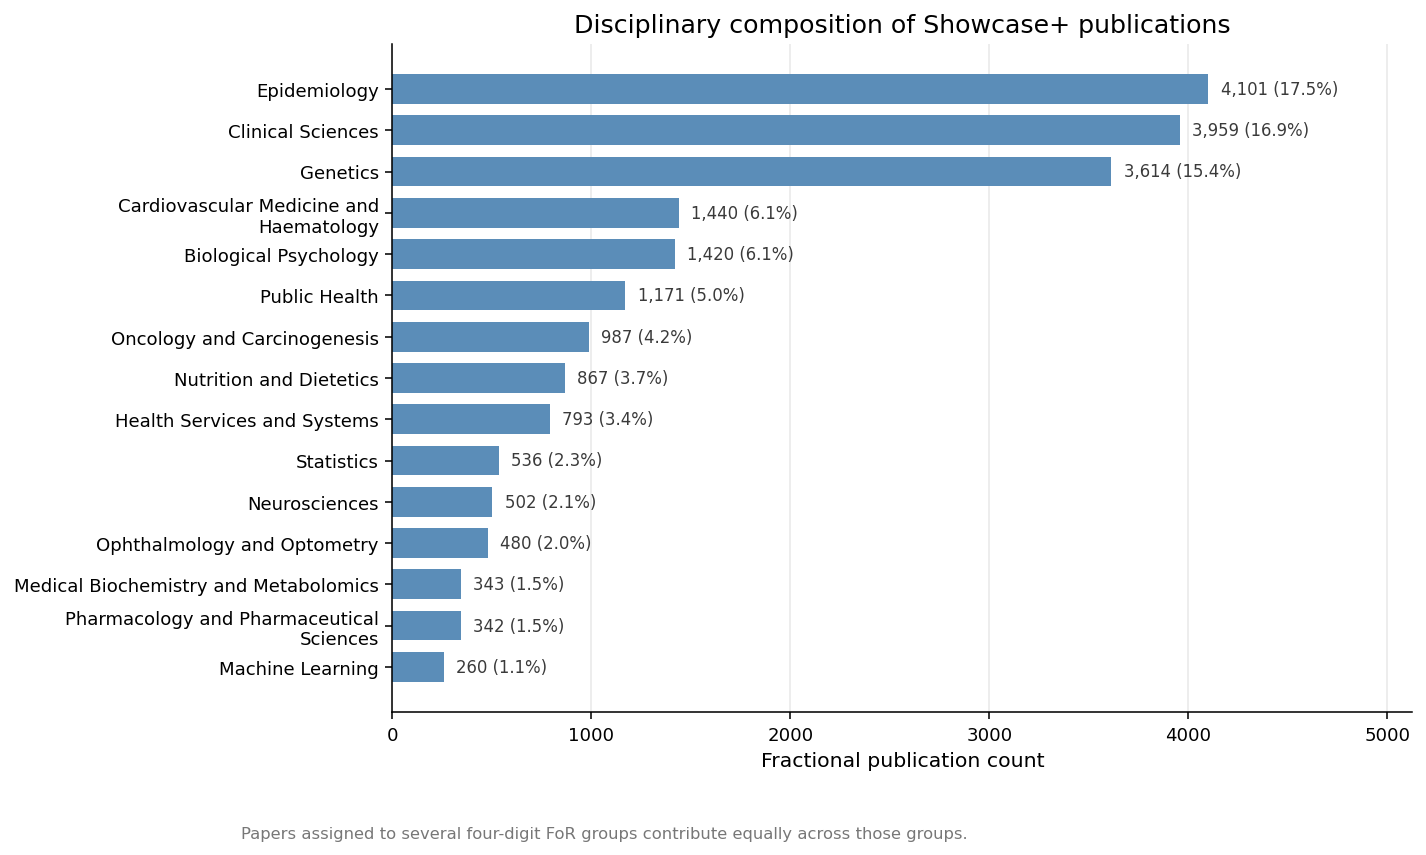

,for_code,for_name,fractional_paper_count,papers,percent_of_corpus
69,4202,Epidemiology,4101.416667,6277,17.499751
15,3202,Clinical Sciences,3959.250000,5466,16.893160
10,3105,Genetics,3614.250000,5328,15.421129
14,3201,Cardiovascular Medicine and Haematology,1439.666667,1906,6.142709
109,5202,Biological Psychology,1419.916667,2245,6.058440
73,4206,Public Health,1170.833333,1878,4.995662
24,3211,Oncology and Carcinogenesis,986.750000,1360,4.210223
23,3210,Nutrition and Dietetics,867.166667,1115,3.699990
70,4203,Health Services and Systems,792.666667,1212,3.382117
103,4905,Statistics,535.833333,1140,2.286271


In [5]:
discipline_summary = (
    for_long.groupby(["for_code", "for_name"], as_index=False)
    .agg(
        fractional_paper_count=("fractional_papers", "sum"),
        papers=("id", "nunique"),
    )
)
discipline_summary["percent_of_corpus"] = (
    100 * discipline_summary["fractional_paper_count"] / analysis_papers["id"].nunique()
)

discipline_plot = (
    discipline_summary.nlargest(TOP_N, "fractional_paper_count")
    .sort_values("fractional_paper_count")
    .copy()
)

figure, axis = plt.subplots(figsize=(9.4, 6.2))
bars = axis.barh(
    np.arange(len(discipline_plot)),
    discipline_plot["fractional_paper_count"],
    color=COLOUR["blue"],
    height=0.72,
)
axis.set_yticks(np.arange(len(discipline_plot)))
axis.set_yticklabels(discipline_plot["for_name"].map(wrapped))
axis.set_xlabel("Fractional publication count")
axis.set_title("Disciplinary composition of Showcase+ publications")
axis.grid(axis="x", color=COLOUR["grey_light"], linewidth=0.8)
axis.set_axisbelow(True)

maximum = discipline_plot["fractional_paper_count"].max()
axis.set_xlim(0, maximum * 1.25)
for bar, row in zip(bars, discipline_plot.itertuples(index=False)):
    axis.text(
        bar.get_width() + maximum * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row.fractional_paper_count:,.0f} ({row.percent_of_corpus:.1f}%)",
        va="center",
        fontsize=8.5,
        color=COLOUR["grey_dark"],
    )

figure.text(
    0.01,
    -0.035,
    "Papers assigned to several four-digit FoR groups contribute equally across those groups.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig01_disciplinary_composition")
plt.show()

discipline_summary.sort_values(
    "fractional_paper_count", ascending=False
).to_csv(TABLE_DIR / "fig01_disciplinary_composition.csv", index=False)
display(discipline_summary.nlargest(TOP_N, "fractional_paper_count"))


## 6. Cumulative publication output and citation stock

This plot places publication growth and citation impact on the same percentage scale. It uses the current citation count attached to each paper, grouped by publication year; it is not a historical record of how many citations existed in each calendar year.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig02_cumulative_output_and_citation_stock.png


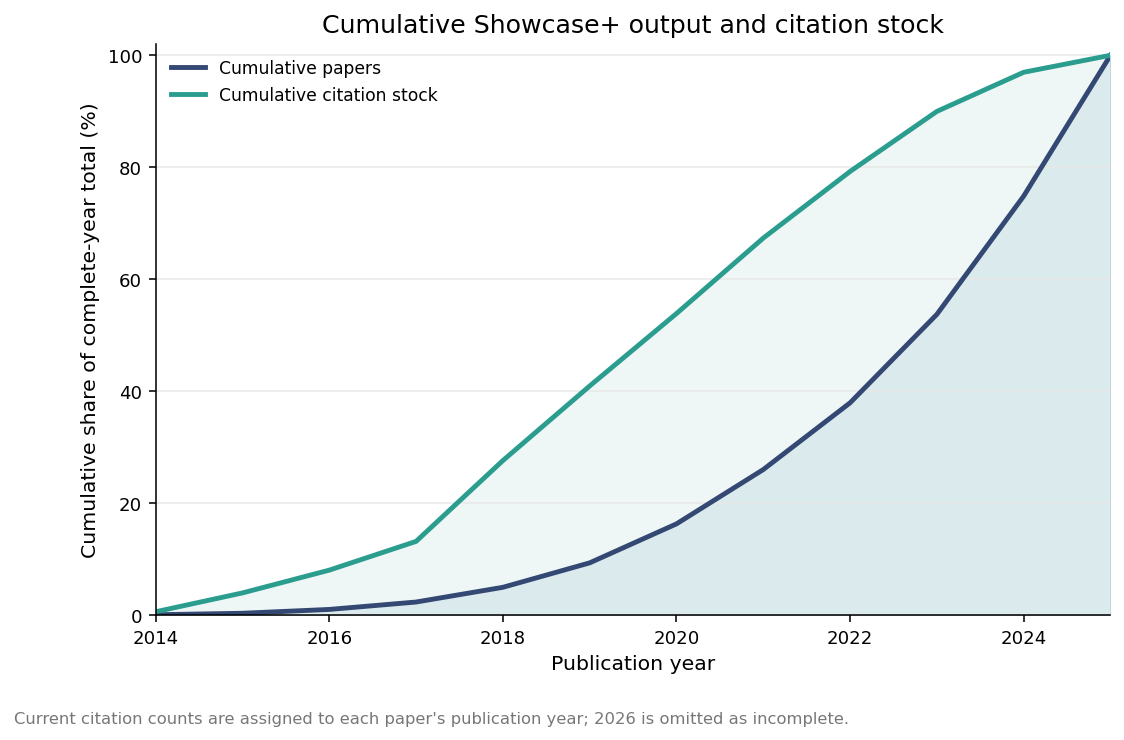

,year,papers,citations,cumulative_papers,cumulative_citations,cumulative_paper_share,cumulative_citation_share
0,2014,27,4377,27,4377,0.115202,0.653639
1,2015,63,22511,90,26888,0.384008,4.015316
2,2016,160,27235,250,54123,1.066689,8.082451
3,2017,310,34371,560,88494,2.389384,13.215239
4,2018,616,96627,1176,185121,5.017707,27.645019
5,2019,1023,89144,2199,274265,9.382600,40.957326
6,2020,1631,86615,3830,360880,16.341682,53.891965
7,2021,2273,90212,6103,451092,26.040022,67.363762
8,2022,2792,79627,8895,530719,37.952810,79.254849
9,2023,3702,71815,12597,602534,53.748347,89.979332


In [6]:
yearly = (
    analysis_papers.groupby("year", as_index=False)
    .agg(
        papers=("id", "nunique"),
        citations=("times_cited", "sum"),
    )
    .sort_values("year")
)
yearly["cumulative_papers"] = yearly["papers"].cumsum()
yearly["cumulative_citations"] = yearly["citations"].cumsum()
yearly["cumulative_paper_share"] = (
    100 * yearly["cumulative_papers"] / yearly["cumulative_papers"].iloc[-1]
)
yearly["cumulative_citation_share"] = (
    100 * yearly["cumulative_citations"] / yearly["cumulative_citations"].iloc[-1]
)

figure, axis = plt.subplots(figsize=(8.8, 5.3))
axis.plot(
    yearly["year"], yearly["cumulative_paper_share"],
    color=COLOUR["blue_dark"], linewidth=2.5, label="Cumulative papers",
)
axis.plot(
    yearly["year"], yearly["cumulative_citation_share"],
    color=COLOUR["teal"], linewidth=2.5, label="Cumulative citation stock",
)
axis.fill_between(
    yearly["year"], 0, yearly["cumulative_paper_share"],
    color=COLOUR["blue"], alpha=0.12,
)
axis.fill_between(
    yearly["year"], 0, yearly["cumulative_citation_share"],
    color=COLOUR["teal"], alpha=0.08,
)
axis.set_xlim(yearly["year"].min(), yearly["year"].max())
axis.set_ylim(0, 102)
axis.set_xticks(np.arange(yearly["year"].min(), yearly["year"].max() + 1, 2))
axis.set_xlabel("Publication year")
axis.set_ylabel("Cumulative share of complete-year total (%)")
axis.set_title("Cumulative Showcase+ output and citation stock")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
axis.legend(frameon=False, loc="upper left")

figure.text(
    0.01,
    -0.035,
    f"Current citation counts are assigned to each paper's publication year; {', '.join(map(str, sorted(INCOMPLETE_YEARS)))} is omitted as incomplete.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig02_cumulative_output_and_citation_stock")
plt.show()

yearly.to_csv(TABLE_DIR / "fig02_cumulative_output_and_citation_stock.csv", index=False)
display(yearly)


## 7. Leading publication venues

Here the bars rank journals by the total citations received by their Showcase+ papers. Colour carries a second piece of information: how many papers each journal contributed. A minimum paper count is applied so that a single exceptional paper does not define the ranking.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig03_leading_venues_by_citations.png


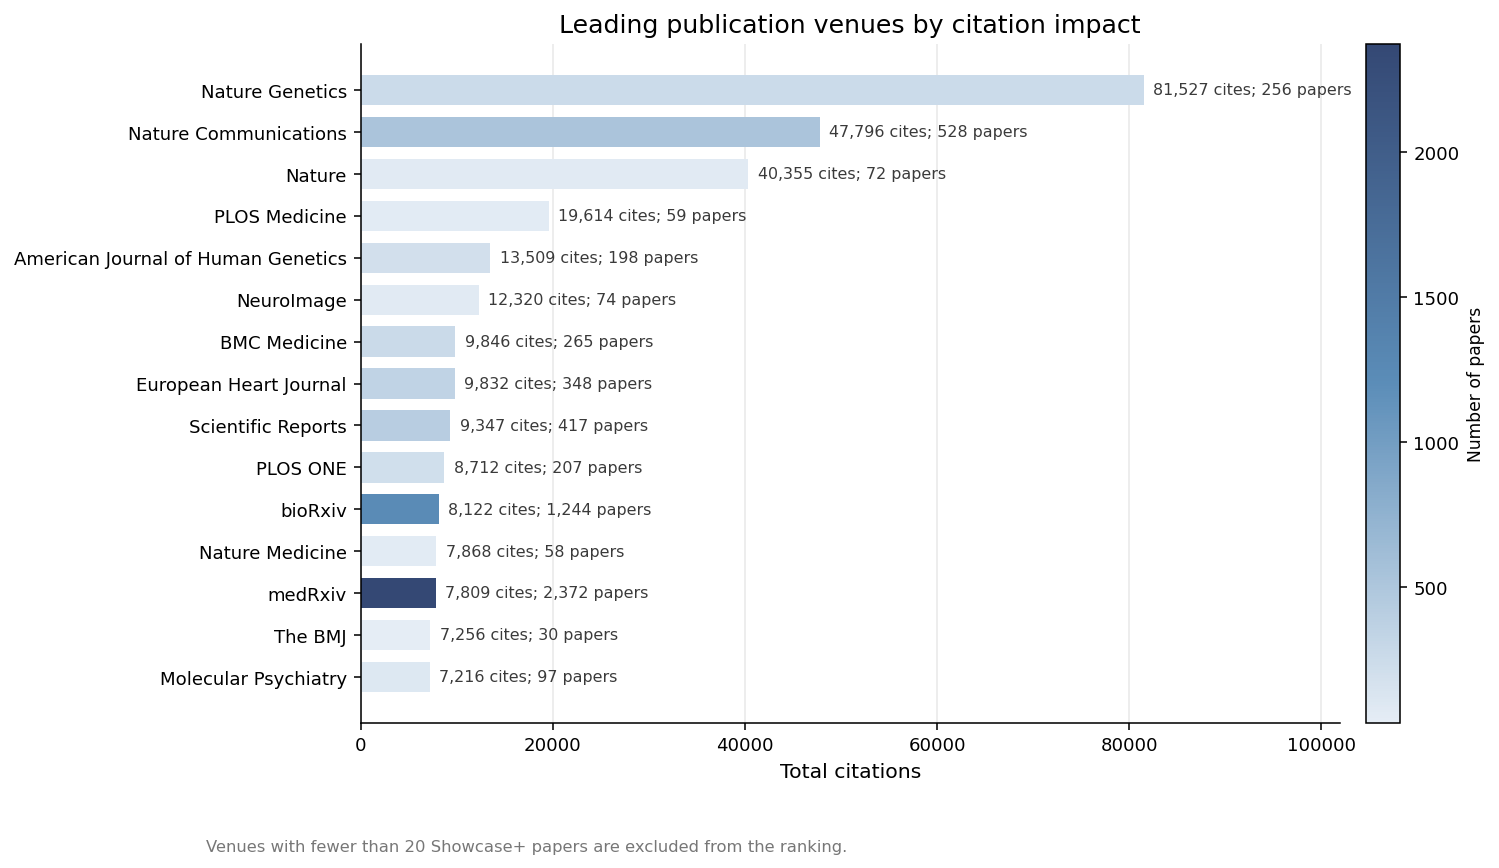

,venue,papers,total_citations,median_citations,median_citations_per_year
1417,Nature Genetics,256,81527,146.5,27.250000
1414,Nature Communications,528,47796,36.0,8.500000
1408,Nature,72,40355,174.0,45.375000
1533,PLOS Medicine,59,19614,74.0,12.571429
70,American Journal of Human Genetics,198,13509,27.0,5.800000
1439,NeuroImage,74,12320,20.0,4.250000
195,BMC Medicine,265,9846,23.0,5.600000
651,European Heart Journal,348,9832,0.0,0.000000
1703,Scientific Reports,417,9347,10.0,2.500000
1536,PLOS ONE,207,8712,11.0,2.000000


In [7]:
venue_summary = (
    analysis_papers[analysis_papers["venue"].ne("")]
    .groupby("venue", as_index=False)
    .agg(
        papers=("id", "nunique"),
        total_citations=("times_cited", "sum"),
        median_citations=("times_cited", "median"),
        median_citations_per_year=("citations_per_year", "median"),
    )
)

venue_plot = (
    venue_summary[venue_summary["papers"].ge(MIN_VENUE_PAPERS)]
    .nlargest(TOP_N, "total_citations")
    .sort_values("total_citations")
    .copy()
)
if venue_plot.empty:
    raise ValueError("No venues meet MIN_VENUE_PAPERS.")

normaliser = Normalize(venue_plot["papers"].min(), venue_plot["papers"].max())
figure, axis = plt.subplots(figsize=(9.6, 6.3))
bars = axis.barh(
    np.arange(len(venue_plot)),
    venue_plot["total_citations"],
    color=impact_cmap(normaliser(venue_plot["papers"])),
    height=0.72,
)
axis.set_yticks(np.arange(len(venue_plot)))
axis.set_yticklabels(venue_plot["venue"].map(lambda value: wrapped(value, 35)))
axis.set_xlabel("Total citations")
axis.set_title("Leading publication venues by citation impact")
axis.grid(axis="x", color=COLOUR["grey_light"], linewidth=0.8)
axis.set_axisbelow(True)

maximum = venue_plot["total_citations"].max()
axis.set_xlim(0, maximum * 1.25)
for bar, row in zip(bars, venue_plot.itertuples(index=False)):
    axis.text(
        bar.get_width() + maximum * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{row.total_citations:,.0f} cites; {row.papers:,} papers",
        va="center",
        fontsize=8.2,
        color=COLOUR["grey_dark"],
    )

mapper = ScalarMappable(norm=normaliser, cmap=impact_cmap)
mapper.set_array([])
colour_bar = figure.colorbar(mapper, ax=axis, fraction=0.035, pad=0.025)
colour_bar.set_label("Number of papers", fontsize=8.8)
figure.text(
    0.01,
    -0.035,
    f"Venues with fewer than {MIN_VENUE_PAPERS} Showcase+ papers are excluded from the ranking.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig03_leading_venues_by_citations")
plt.show()

venue_summary.sort_values("total_citations", ascending=False).to_csv(
    TABLE_DIR / "fig03_venue_impact.csv", index=False
)
display(venue_summary.nlargest(TOP_N, "total_citations"))


## 8. Citation impact by Field of Research

The same fractional rule is used for citations: if a paper belongs to two four-digit FoR groups, each receives half of that paper's citation count. The bars therefore show how citation impact is distributed without inflating the overall total.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig04_field_citation_impact.png


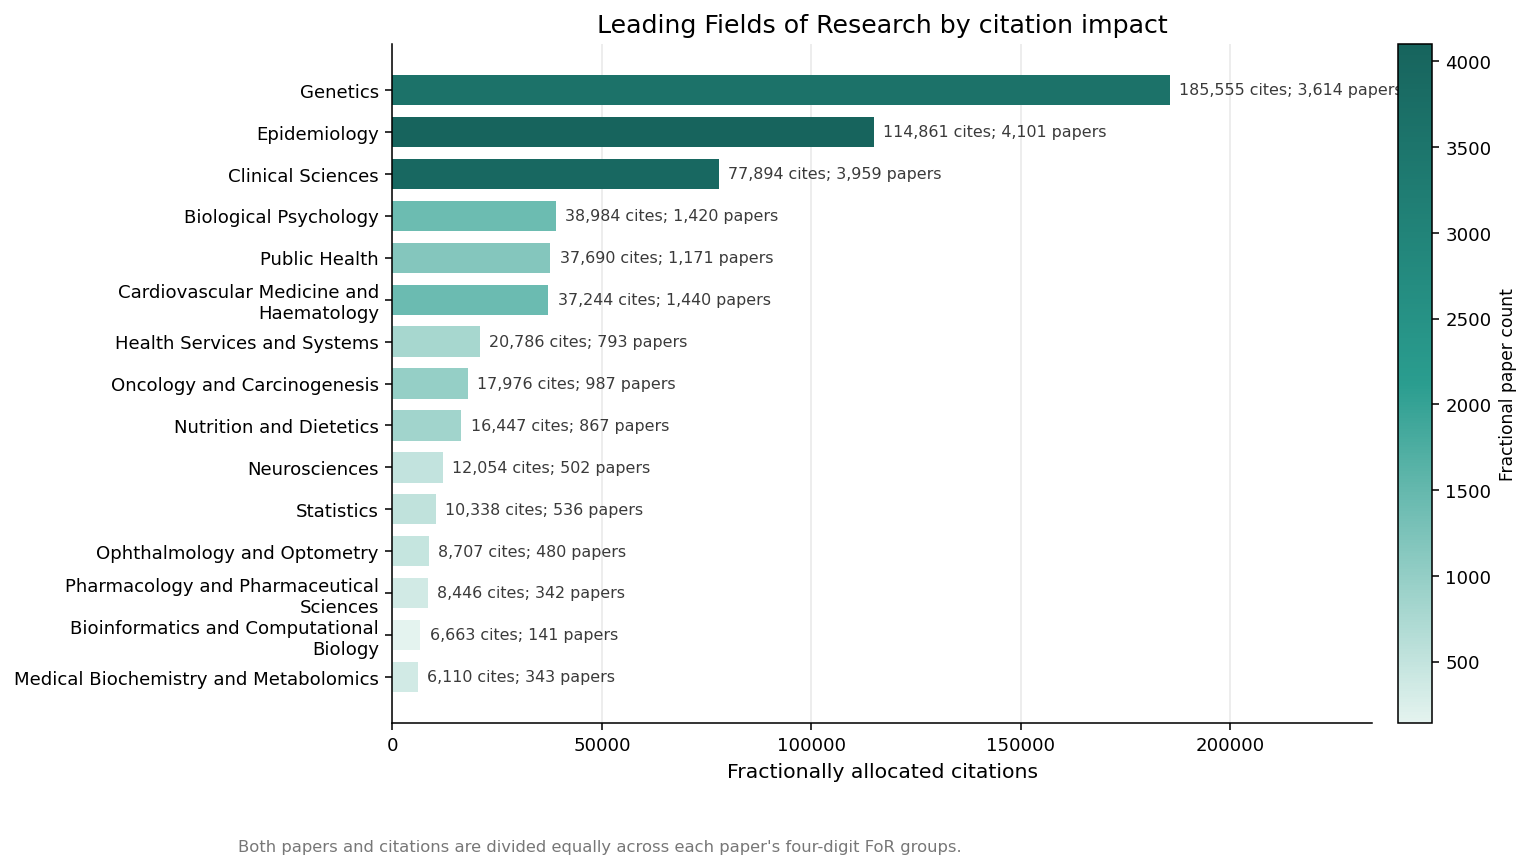

,for_code,for_name,fractional_papers,papers,fractional_citations,citations_per_fractional_paper
10,3105,Genetics,3614.250000,5328,185554.583333,51.339720
69,4202,Epidemiology,4101.416667,6277,114861.250000,28.005262
15,3202,Clinical Sciences,3959.250000,5466,77894.166667,19.673970
109,5202,Biological Psychology,1419.916667,2245,38983.833333,27.455015
73,4206,Public Health,1170.833333,1878,37690.500000,32.191174
14,3201,Cardiovascular Medicine and Haematology,1439.666667,1906,37243.500000,25.869530
70,4203,Health Services and Systems,792.666667,1212,20785.750000,26.222561
24,3211,Oncology and Carcinogenesis,986.750000,1360,17976.250000,18.217634
23,3210,Nutrition and Dietetics,867.166667,1115,16446.750000,18.966077
22,3209,Neurosciences,502.500000,1114,12054.166667,23.988391


In [8]:
field_impact = (
    for_long.groupby(["for_code", "for_name"], as_index=False)
    .agg(
        fractional_papers=("fractional_papers", "sum"),
        papers=("id", "nunique"),
        fractional_citations=("fractional_citations", "sum"),
    )
)
field_impact["citations_per_fractional_paper"] = (
    field_impact["fractional_citations"] / field_impact["fractional_papers"]
)

field_plot = (
    field_impact.nlargest(TOP_N, "fractional_citations")
    .sort_values("fractional_citations")
    .copy()
)
normaliser = Normalize(
    field_plot["fractional_papers"].min(),
    field_plot["fractional_papers"].max(),
)

figure, axis = plt.subplots(figsize=(9.6, 6.3))
bars = axis.barh(
    np.arange(len(field_plot)),
    field_plot["fractional_citations"],
    color=field_cmap(normaliser(field_plot["fractional_papers"])),
    height=0.72,
)
axis.set_yticks(np.arange(len(field_plot)))
axis.set_yticklabels(field_plot["for_name"].map(wrapped))
axis.set_xlabel("Fractionally allocated citations")
axis.set_title("Leading Fields of Research by citation impact")
axis.grid(axis="x", color=COLOUR["grey_light"], linewidth=0.8)
axis.set_axisbelow(True)

maximum = field_plot["fractional_citations"].max()
axis.set_xlim(0, maximum * 1.26)
for bar, row in zip(bars, field_plot.itertuples(index=False)):
    axis.text(
        bar.get_width() + maximum * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{row.fractional_citations:,.0f} cites; {row.fractional_papers:,.0f} papers",
        va="center",
        fontsize=8.2,
        color=COLOUR["grey_dark"],
    )

mapper = ScalarMappable(norm=normaliser, cmap=field_cmap)
mapper.set_array([])
colour_bar = figure.colorbar(mapper, ax=axis, fraction=0.035, pad=0.025)
colour_bar.set_label("Fractional paper count", fontsize=8.8)
figure.text(
    0.01,
    -0.035,
    "Both papers and citations are divided equally across each paper's four-digit FoR groups.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig04_field_citation_impact")
plt.show()

field_impact.sort_values("fractional_citations", ascending=False).to_csv(
    TABLE_DIR / "fig04_field_citation_impact.csv", index=False
)
display(field_impact.nlargest(TOP_N, "fractional_citations"))


## 9. Citation concentration

This curve orders papers from most to least cited. It answers a straightforward question: what share of all citations is carried by the top 1%, 5%, 10%, and so on? The diagonal is the equal-share reference.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig05_citation_concentration.png


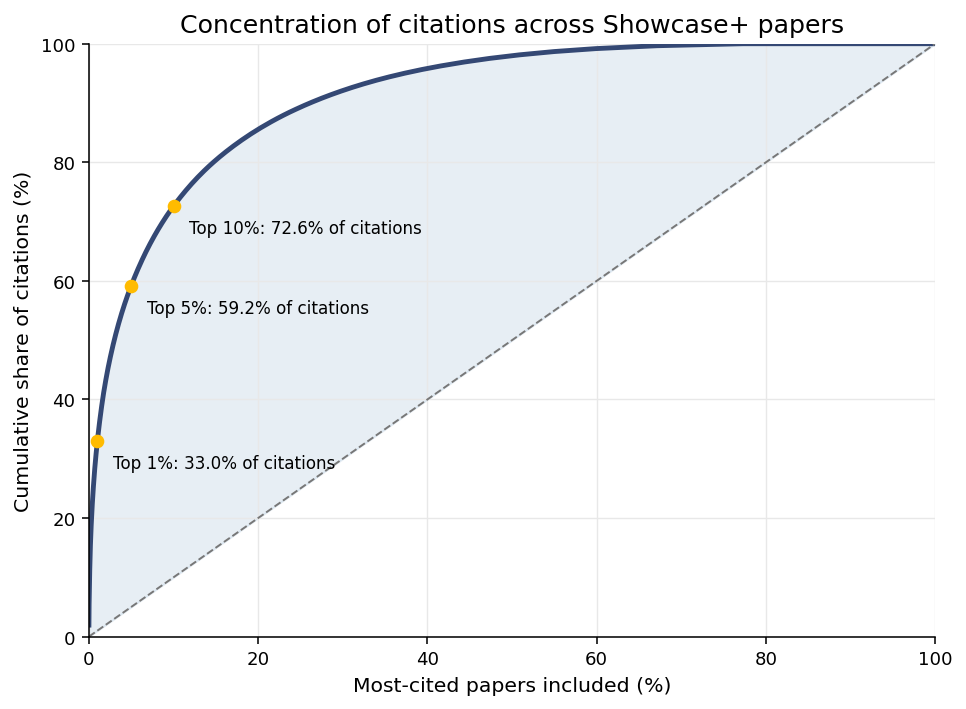

,top_paper_percent,citation_percent
0,1,32.986876
1,5,59.199774
2,10,72.612584
3,20,85.557825
4,50,97.986966


In [9]:
ordered_citations = analysis_papers["times_cited"].clip(lower=0).sort_values(
    ascending=False
).reset_index(drop=True)
total_citations = ordered_citations.sum()
if total_citations <= 0:
    raise ValueError("Citation concentration cannot be calculated because all counts are zero.")

concentration = pd.DataFrame({
    "top_paper_share": 100 * np.arange(1, len(ordered_citations) + 1) / len(ordered_citations),
    "citation_share": 100 * ordered_citations.cumsum() / total_citations,
})

checkpoints = []
for top_share in (1, 5, 10, 20, 50):
    index = max(0, int(np.ceil(len(ordered_citations) * top_share / 100)) - 1)
    checkpoints.append({
        "top_paper_percent": top_share,
        "citation_percent": concentration.iloc[index]["citation_share"],
    })
checkpoint_table = pd.DataFrame(checkpoints)

figure, axis = plt.subplots(figsize=(7.8, 5.5))
axis.plot(
    concentration["top_paper_share"],
    concentration["citation_share"],
    color=COLOUR["blue_dark"],
    linewidth=2.5,
)
axis.fill_between(
    concentration["top_paper_share"],
    concentration["citation_share"],
    concentration["top_paper_share"],
    where=concentration["citation_share"].ge(concentration["top_paper_share"]),
    color=COLOUR["blue"],
    alpha=0.14,
)
axis.plot([0, 100], [0, 100], color=COLOUR["grey"], linestyle="--", linewidth=1)

for row in checkpoint_table.itertuples(index=False):
    if row.top_paper_percent in {1, 5, 10}:
        axis.scatter(row.top_paper_percent, row.citation_percent, color=COLOUR["gold"], zorder=3)
        axis.annotate(
            f"Top {row.top_paper_percent}%: {row.citation_percent:.1f}% of citations",
            (row.top_paper_percent, row.citation_percent),
            xytext=(8, -14),
            textcoords="offset points",
            fontsize=8.6,
        )

axis.set_xlim(0, 100)
axis.set_ylim(0, 100)
axis.set_xlabel("Most-cited papers included (%)")
axis.set_ylabel("Cumulative share of citations (%)")
axis.set_title("Concentration of citations across Showcase+ papers")
axis.grid(color=COLOUR["grey_light"], linewidth=0.7)
save_figure(figure, "fig05_citation_concentration")
plt.show()

concentration.to_csv(TABLE_DIR / "fig05_citation_concentration_curve.csv", index=False)
checkpoint_table.to_csv(TABLE_DIR / "fig05_citation_concentration_checkpoints.csv", index=False)
display(checkpoint_table)


## 10. Age-adjusted citation impact by publication cohort

Older papers have had more time to collect citations. To make broad cohorts easier to compare, each paper's current citation count is divided by the number of years since publication. The distributions are still descriptive: this adjustment handles exposure time, not differences between research fields.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig06_age_adjusted_citation_cohorts.png


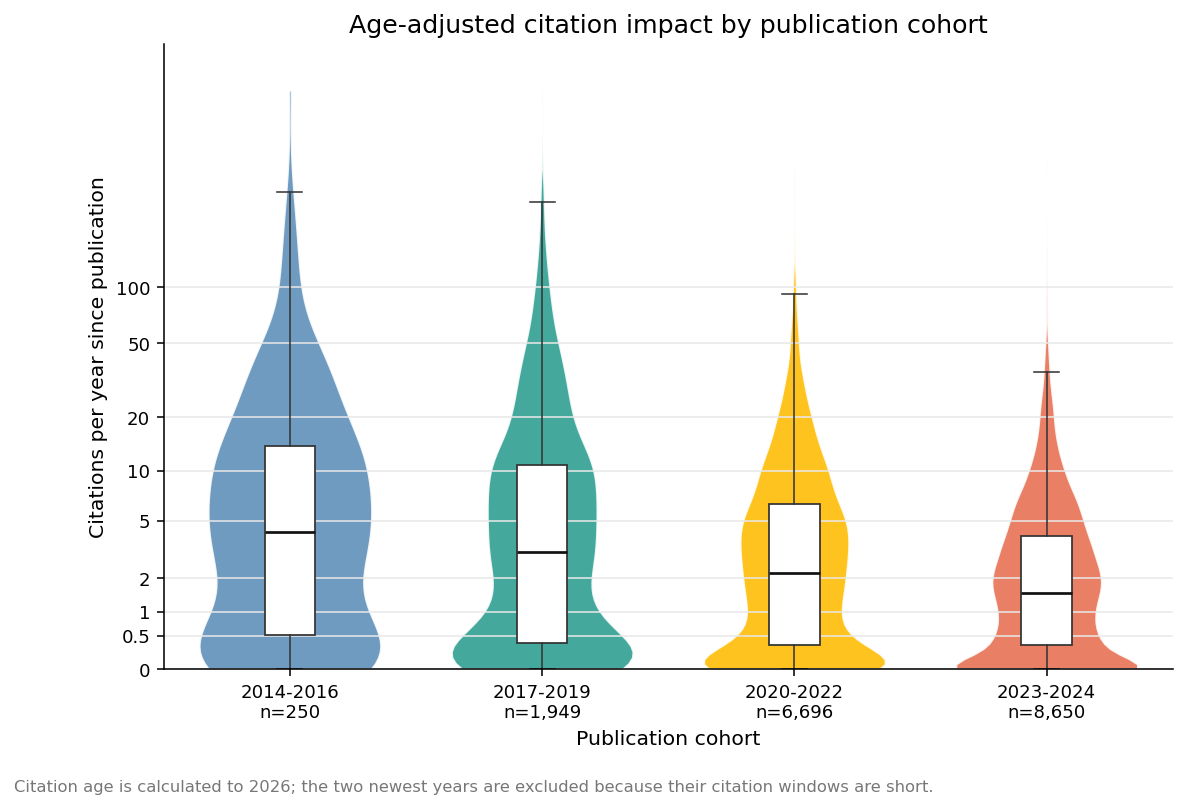

,cohort,papers,median_citations_per_year,p90_citations_per_year,top_decile_share
0,2014-2016,250,4.261364,34.481818,26.000000
1,2017-2019,1949,3.111111,29.800000,20.933812
2,2020-2022,6696,2.200000,14.800000,11.887694
3,2023-2024,8650,1.500000,8.750000,5.895954


In [10]:
IMPACT_MAX_YEAR = CITATION_SNAPSHOT_YEAR - 2
cohort_papers = analysis_papers[analysis_papers["year"].le(IMPACT_MAX_YEAR)].copy()
cohort_papers["log_citations_per_year"] = np.log10(
    cohort_papers["citations_per_year"] + 1
)

cohort_edges = list(range(MIN_YEAR, IMPACT_MAX_YEAR + 2, 3))
if cohort_edges[-1] <= IMPACT_MAX_YEAR:
    cohort_edges.append(IMPACT_MAX_YEAR + 1)
cohort_labels = [
    f"{start}-{end - 1}" for start, end in zip(cohort_edges[:-1], cohort_edges[1:])
]
cohort_papers["cohort"] = pd.cut(
    cohort_papers["year"],
    bins=cohort_edges,
    labels=cohort_labels,
    right=False,
    include_lowest=True,
)

top_decile_threshold = cohort_papers["citations_per_year"].quantile(0.90)
cohort_summary = (
    cohort_papers.dropna(subset=["cohort"])
    .groupby("cohort", observed=True)
    .agg(
        papers=("id", "nunique"),
        median_citations_per_year=("citations_per_year", "median"),
        p90_citations_per_year=("citations_per_year", lambda values: values.quantile(0.90)),
        top_decile_share=("citations_per_year", lambda values: 100 * values.ge(top_decile_threshold).mean()),
    )
    .reset_index()
)

plot_labels = cohort_summary["cohort"].astype(str).tolist()
plot_values = [
    cohort_papers.loc[
        cohort_papers["cohort"].astype(str).eq(label),
        "log_citations_per_year",
    ].dropna().to_numpy()
    for label in plot_labels
]
positions = np.arange(len(plot_values))

figure, axis = plt.subplots(figsize=(9.3, 5.8))
violins = axis.violinplot(
    plot_values,
    positions=positions,
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
palette = [COLOUR["blue"], COLOUR["teal"], COLOUR["gold"], COLOUR["coral"], COLOUR["purple"]]
for body, colour in zip(violins["bodies"], palette):
    body.set_facecolor(colour)
    body.set_edgecolor("white")
    body.set_alpha(0.88)

axis.boxplot(
    plot_values,
    positions=positions,
    widths=0.20,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#111111", "linewidth": 1.4},
    boxprops={"facecolor": "white", "edgecolor": "#333333", "linewidth": 0.9},
    whiskerprops={"color": "#333333", "linewidth": 0.8},
    capprops={"color": "#333333", "linewidth": 0.8},
)

axis.set_xticks(positions)
axis.set_xticklabels([
    f"{row.cohort}\nn={row.papers:,}" for row in cohort_summary.itertuples(index=False)
])
raw_ticks = np.array([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
log_ticks = np.log10(raw_ticks + 1)
upper_limit = max(np.nanmax(values) for values in plot_values) * 1.08
keep = log_ticks <= upper_limit
axis.set_yticks(log_ticks[keep])
axis.set_yticklabels([f"{value:g}" for value in raw_ticks[keep]])
axis.set_ylim(0, upper_limit)
axis.set_xlabel("Publication cohort")
axis.set_ylabel("Citations per year since publication")
axis.set_title("Age-adjusted citation impact by publication cohort")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
figure.text(
    0.01,
    -0.04,
    f"Citation age is calculated to {CITATION_SNAPSHOT_YEAR}; the two newest years are excluded because their citation windows are short.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig06_age_adjusted_citation_cohorts")
plt.show()

cohort_summary.to_csv(TABLE_DIR / "fig06_age_adjusted_citation_cohorts.csv", index=False)
display(cohort_summary)


## 11. Field-normalised citation performance

Field Citation Ratio is available for many, but not all, publications. A value of one is the Dimensions benchmark; values above one indicate citation performance above that benchmark. The curve shows the full distribution rather than reducing it to a single mean. If FCR is unavailable in a future export, the cell falls back to RCR and then to citations per year.


Saved: /content/drive/MyDrive/UKB_BERTopic_seed_robustness/output/non_topic_figures/figures/fig07_normalised_citation_performance.png


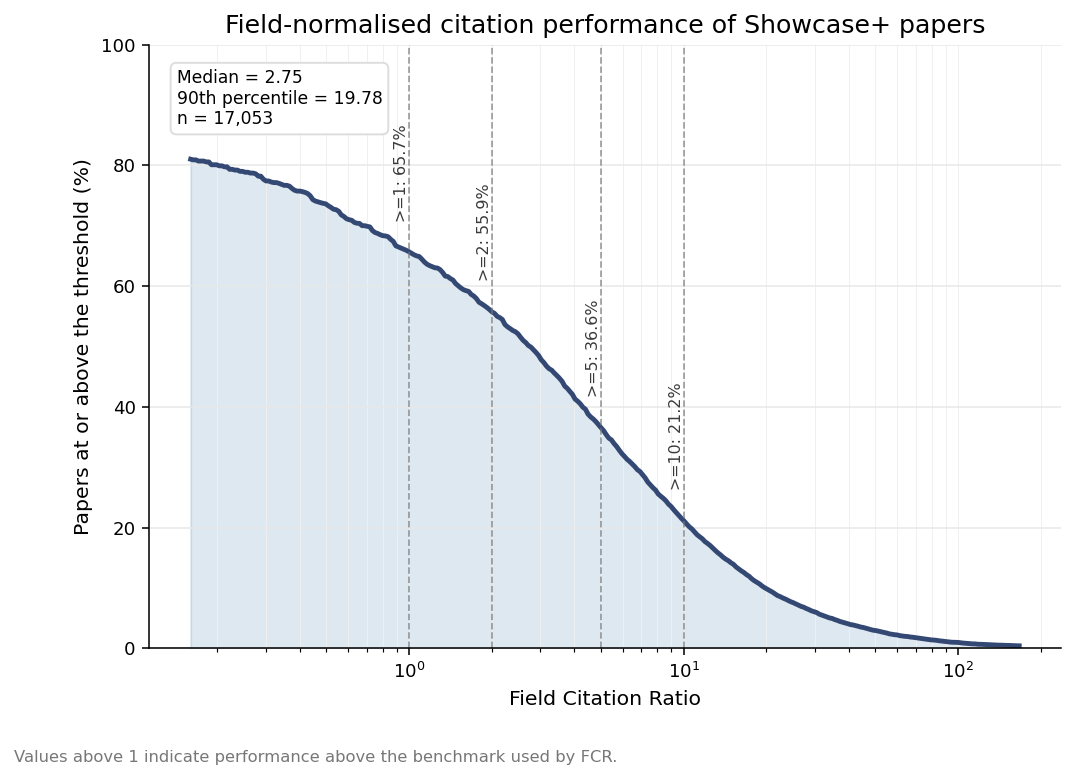

,threshold,papers_at_or_above,percent_at_or_above
0,1,11205,65.706914
1,2,9533,55.902187
2,5,6248,36.638715
3,10,3609,21.163432


In [11]:
metric_candidates = [
    ("field_citation_ratio", "Field Citation Ratio", "FCR"),
    ("relative_citation_ratio", "Relative Citation Ratio", "RCR"),
    ("citations_per_year", "Citations per year", "annualised citations"),
]
for metric_column, metric_label, metric_short in metric_candidates:
    valid_metric = analysis_papers[metric_column].replace([np.inf, -np.inf], np.nan).dropna()
    valid_metric = valid_metric[valid_metric.ge(0)]
    if len(valid_metric) >= 100:
        break
else:
    raise ValueError("No citation impact metric has enough valid values.")

positive_metric = valid_metric[valid_metric.gt(0)]
if positive_metric.empty:
    raise ValueError(f"{metric_label} has no positive values.")

x_min = max(float(positive_metric.quantile(0.005)), 0.02)
x_max = float(positive_metric.quantile(0.995))
x_grid = np.logspace(np.log10(x_min), np.log10(x_max), 320)
y_share = np.array([100 * valid_metric.ge(value).mean() for value in x_grid])

thresholds = [1, 2, 5, 10]
threshold_summary = pd.DataFrame({
    "threshold": thresholds,
    "papers_at_or_above": [int(valid_metric.ge(value).sum()) for value in thresholds],
    "percent_at_or_above": [100 * valid_metric.ge(value).mean() for value in thresholds],
})

figure, axis = plt.subplots(figsize=(8.4, 5.6))
axis.plot(x_grid, y_share, color=COLOUR["blue_dark"], linewidth=2.5)
axis.fill_between(x_grid, y_share, 0, color=COLOUR["blue"], alpha=0.20)

for row in threshold_summary.itertuples(index=False):
    if x_min <= row.threshold <= x_max:
        axis.axvline(
            row.threshold,
            color=COLOUR["grey"],
            linewidth=0.9,
            linestyle="--",
            alpha=0.7,
        )
        axis.text(
            row.threshold,
            min(96, row.percent_at_or_above + 5),
            f">={row.threshold:g}: {row.percent_at_or_above:.1f}%",
            rotation=90,
            ha="right",
            va="bottom",
            fontsize=8.2,
            color=COLOUR["grey_dark"],
        )

axis.set_xscale("log")
axis.set_ylim(0, 100)
axis.set_xlabel(metric_label)
axis.set_ylabel("Papers at or above the threshold (%)")
axis.set_title("Field-normalised citation performance of Showcase+ papers")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
axis.grid(axis="x", color="#F0F0F0", linewidth=0.5, which="both")
axis.text(
    0.03,
    0.96,
    f"Median = {valid_metric.median():.2f}\n90th percentile = {valid_metric.quantile(0.90):.2f}\nn = {len(valid_metric):,}",
    transform=axis.transAxes,
    ha="left",
    va="top",
    fontsize=8.8,
    bbox={"facecolor": "white", "edgecolor": "#DDDDDD", "boxstyle": "round,pad=0.35"},
)

note = (
    f"Values above 1 indicate performance above the benchmark used by {metric_short}."
    if metric_short in {"FCR", "RCR"}
    else "A field-normalised ratio was unavailable, so citations per year are shown."
)
figure.text(0.01, -0.035, note, fontsize=8.4, color=COLOUR["grey"])
save_figure(figure, "fig07_normalised_citation_performance")
plt.show()

threshold_summary.to_csv(
    TABLE_DIR / "fig07_normalised_citation_thresholds.csv", index=False
)
display(threshold_summary)


## 12. Output check

The final cell lists the files written by this run. The notebook itself remains the readable record of how each figure was calculated.


In [12]:
figure_files = sorted(FIGURE_DIR.glob("*.png"))
table_files = sorted(TABLE_DIR.glob("*.csv"))

print(f"Created {len(figure_files)} PNG figures (with matching PDF and SVG files).")
for path in figure_files:
    print(" -", path.name)

print(f"\nCreated {len(table_files)} analysis tables.")
for path in table_files:
    print(" -", path.name)


Created 7 PNG figures (with matching PDF and SVG files).
 - fig01_disciplinary_composition.png
 - fig02_cumulative_output_and_citation_stock.png
 - fig03_leading_venues_by_citations.png
 - fig04_field_citation_impact.png
 - fig05_citation_concentration.png
 - fig06_age_adjusted_citation_cohorts.png
 - fig07_normalised_citation_performance.png

Created 8 analysis tables.
 - fig01_disciplinary_composition.csv
 - fig02_cumulative_output_and_citation_stock.csv
 - fig03_venue_impact.csv
 - fig04_field_citation_impact.csv
 - fig05_citation_concentration_checkpoints.csv
 - fig05_citation_concentration_curve.csv
 - fig06_age_adjusted_citation_cohorts.csv
 - fig07_normalised_citation_thresholds.csv
